# Box-Jenkins Zeitreihenanalyse: Gold (GC=F)
> **Projekt:** Asset Forecasting — DAX, Gold & Bitcoin  
> **Kurs:** Vertiefung Business Analytics · THWS · SoSe 2026  
> **Prof.:** Dr. Christian Menden  
> **Autor:** Antonio Sicaja  
> **Asset:** Gold (Ticker: `GC=F`) · täglich · 2016–2026

---

## Methodik

Wir folgen der klassischen **Box-Jenkins-Methode** in vier Schritten:

1. **Identifikation** — Stationaritätsprüfung (ADF, KPSS), ACF/PACF
2. **Schätzung** — Gittersuche über ARIMA(p,d,q)
3. **Diagnostik** — Residualanalyse (Ljung-Box, Normalverteilung)
4. **Prognose** — 10-Perioden-Forecast mit 95%-Konfidenzintervall

In [8]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

import yfinance as yf

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot-Stil
plt.style.use('seaborn-v0_8-darkgrid')
GOLD = '#FFD700'
BLUE = '#2196F3'
RED  = '#F44336'
GREEN = '#4CAF50'

print('Setup abgeschlossen ✓')

Setup abgeschlossen ✓


---
## 1. Daten laden & aufbereiten

In [9]:
# Daten via yfinance laden (gecacht in data/raw/)
import os
CACHE_PATH = '../data/raw/gold_GC=F.csv'

if os.path.exists(CACHE_PATH):
    df = pd.read_csv(CACHE_PATH, index_col='Date', parse_dates=True)
    print(f'Cache geladen: {CACHE_PATH}')
else:
    raw = yf.download('GC=F', start='2016-01-01', end='2026-05-01',
                      auto_adjust=True, progress=False)
    # Flatten MultiIndex falls vorhanden
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    df.to_csv(CACHE_PATH)
    print(f'Daten heruntergeladen und gecacht: {CACHE_PATH}')

close = df['Close'].dropna()
print(f'\nZeitraum : {close.index[0].date()} → {close.index[-1].date()}')
print(f'Handelstage: {len(close)}')
print(f'Preis Start : {close.iloc[0]:.2f} USD/oz')
print(f'Preis Ende  : {close.iloc[-1]:.2f} USD/oz')
print(f'Gesamtrendite: {(close.iloc[-1]/close.iloc[0] - 1)*100:.1f}%')

Daten heruntergeladen und gecacht: ../data/raw/gold_GC=F.csv

Zeitraum : 2016-01-04 → 2026-04-30
Handelstage: 2595
Preis Start : 1075.10 USD/oz
Preis Ende  : 4614.70 USD/oz
Gesamtrendite: 329.2%


In [13]:
# Deskriptive Statistiken
log_ret = np.log(close).diff().dropna()

desc = pd.DataFrame({
    'Preis (USD/oz)': close.describe(),
    'Log-Returns': log_ret.describe()
})
print(desc.round(6))

# Schiefe & Kurtosis
print(f'\nLog-Returns:')
print(f'  Schiefe  : {log_ret.skew():.4f}')
print(f'  Kurtosis : {log_ret.kurtosis():.4f}  (Normal = 0, Leptokurtisch > 0)')

       Preis (USD/oz)  Log-Returns
count     2595.000000  2594.000000
mean      1927.530673     0.000562
std        841.693304     0.010430
min       1073.900024    -0.120657
25%       1305.950012    -0.004171
50%       1773.599976     0.000668
75%       1988.500000     0.005948
max       5318.399902     0.059054

Log-Returns:
  Schiefe  : -0.7993
  Kurtosis : 10.6006  (Normal = 0, Leptokurtisch > 0)


---
## 2. Explorative Analyse (EDA)

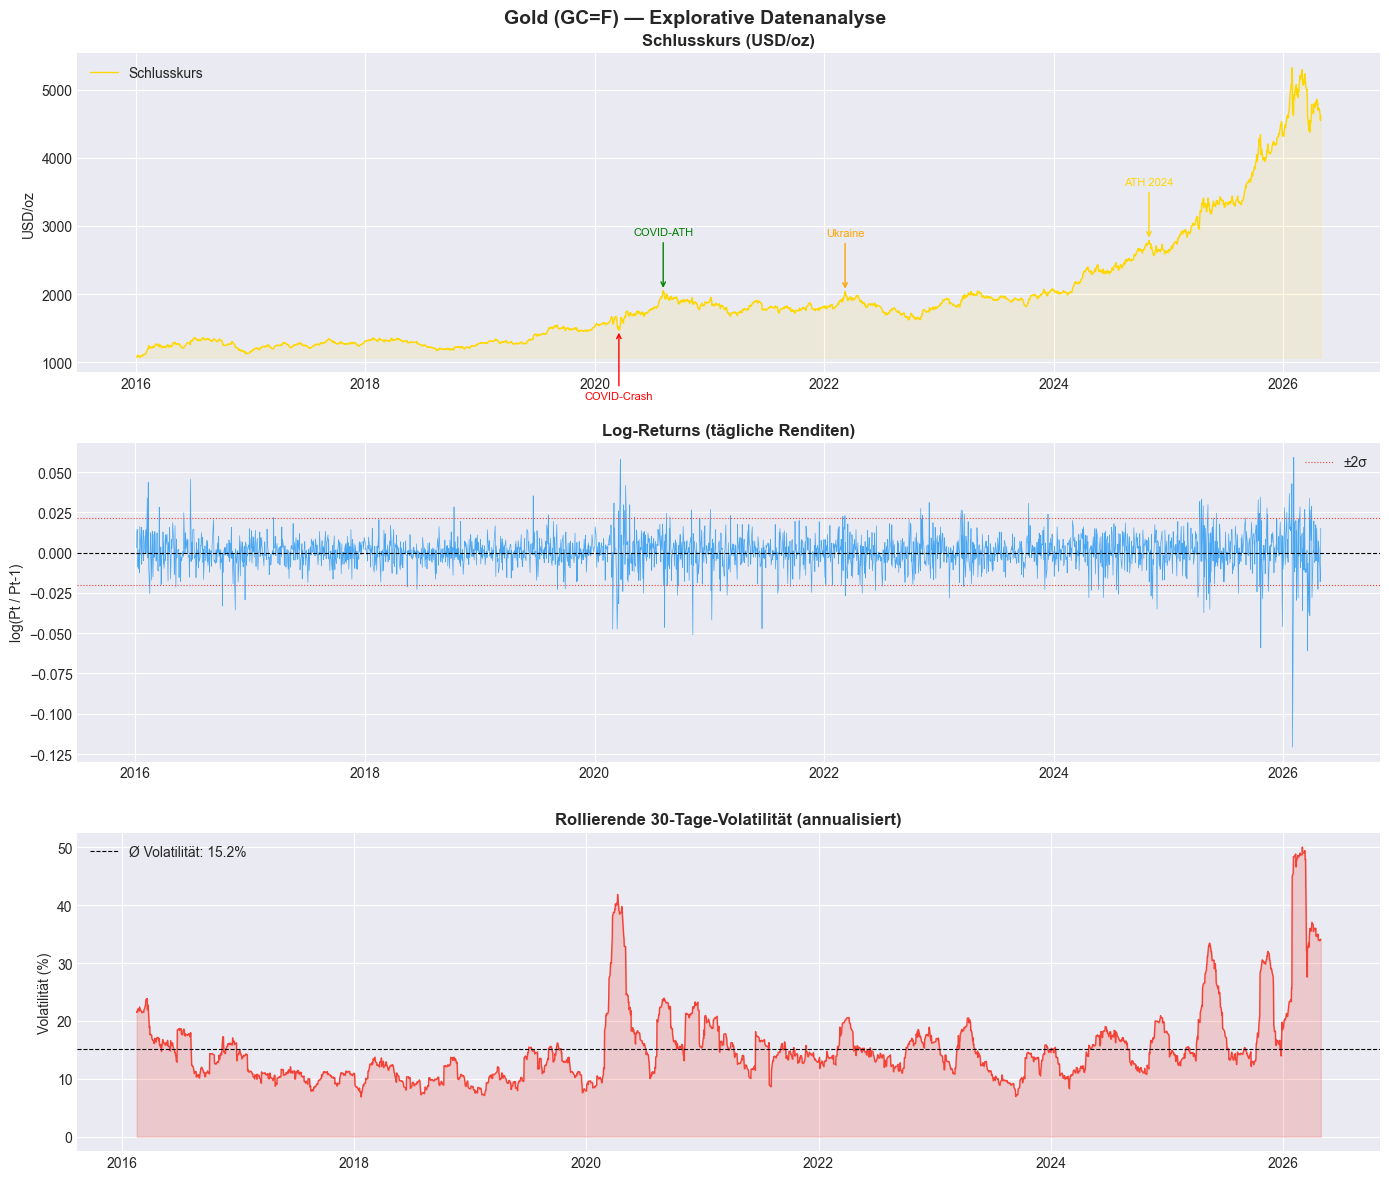

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Gold (GC=F) — Explorative Datenanalyse', fontsize=14, fontweight='bold')

# Preisverlauf
axes[0].plot(close, color=GOLD, linewidth=1.0, label='Schlusskurs')
axes[0].fill_between(close.index, close, close.min(), alpha=0.1, color=GOLD)
axes[0].set_title('Schlusskurs (USD/oz)', fontweight='bold')
axes[0].set_ylabel('USD/oz')
# Ereignisse markieren
events = [
    ('2020-03-18', 'COVID-Crash', 'red', -50),
    ('2020-08-06', 'COVID-ATH', 'green', 40),
    ('2022-03-08', 'Ukraine', 'orange', 40),
    ('2024-10-30', 'ATH 2024', 'gold', 40),
]
for date, label, color, yoff in events:
    idx = close.index.get_indexer([date], method='nearest')[0]
    axes[0].annotate(label, xy=(close.index[idx], close.iloc[idx]),
                     xytext=(0, yoff), textcoords='offset points',
                     fontsize=8, color=color, ha='center',
                     arrowprops=dict(arrowstyle='->', color=color, lw=1.0))
axes[0].legend()

# Log-Returns
axes[1].plot(log_ret, color=BLUE, linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(log_ret.mean() + 2*log_ret.std(), color=RED, linewidth=0.8,
                linestyle=':', label='±2σ')
axes[1].axhline(log_ret.mean() - 2*log_ret.std(), color=RED, linewidth=0.8, linestyle=':')
axes[1].set_title('Log-Returns (tägliche Renditen)', fontweight='bold')
axes[1].set_ylabel('log(Pt / Pt-1)')
axes[1].legend()

# Rollierende Volatilität (30-Tage)
rolling_vol = log_ret.rolling(30).std() * np.sqrt(252) * 100
axes[2].plot(rolling_vol, color=RED, linewidth=1.0)
axes[2].fill_between(rolling_vol.index, rolling_vol, alpha=0.2, color=RED)
axes[2].axhline(rolling_vol.mean(), color='black', linewidth=0.8, linestyle='--',
                label=f'Ø Volatilität: {rolling_vol.mean():.1f}%')
axes[2].set_title('Rollierende 30-Tage-Volatilität (annualisiert)', fontweight='bold')
axes[2].set_ylabel('Volatilität (%)')
axes[2].legend()

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/gold_eda.png', dpi=150, bbox_inches='tight')
plt.show()
plt.show()

---
## 3. Stationaritätsprüfung (Box-Jenkins Schritt 1: Identifikation)

In [16]:
def adf_test(series, name=''):
    """Augmented Dickey-Fuller Test."""
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval, lags, nobs, crit = result[0], result[1], result[2], result[3], result[4]
    print(f'ADF-Test: {name}')
    print(f'  Teststatistik : {stat:.4f}')
    print(f'  p-Wert        : {pval:.4f}  → {"✅ Stationär" if pval < 0.05 else "❌ Nicht stationär"} (α=5%)')
    print(f'  Kritische Werte: 1%={crit["1%"]:.3f}, 5%={crit["5%"]:.3f}, 10%={crit["10%"]:.3f}')
    print()
    return pval

def kpss_test(series, name=''):
    """KPSS Test (Nullhypothese: stationär)."""
    stat, pval, lags, crit = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS-Test: {name}')
    print(f'  Teststatistik : {stat:.4f}')
    print(f'  p-Wert        : {pval:.4f}  → {"❌ Nicht stationär" if pval < 0.05 else "✅ Stationär"} (α=5%)')
    print(f'  Kritische Werte: 1%={crit["1%"]:.3f}, 5%={crit["5%"]:.3f}')
    print()
    return pval

print('='*55)
print('STATIONARITÄTSPRÜFUNG — NIVEAUPREISE')
print('='*55)
adf_test(close, 'Gold Schlusskurs')
kpss_test(close, 'Gold Schlusskurs')

print('='*55)
print('STATIONARITÄTSPRÜFUNG — LOG-RETURNS (1. Differenz)')
print('='*55)
adf_test(log_ret, 'Gold Log-Returns')
kpss_test(log_ret, 'Gold Log-Returns')

print('→ Fazit: Niveaupreise sind I(1) (integriert der Ordnung 1).')
print('  Log-Returns sind I(0) (stationär) → d=1 im ARIMA-Modell.')

STATIONARITÄTSPRÜFUNG — NIVEAUPREISE
ADF-Test: Gold Schlusskurs
  Teststatistik : 2.3782
  p-Wert        : 0.9990  → ❌ Nicht stationär (α=5%)
  Kritische Werte: 1%=-3.433, 5%=-2.863, 10%=-2.567

KPSS-Test: Gold Schlusskurs
  Teststatistik : 5.7666
  p-Wert        : 0.0100  → ❌ Nicht stationär (α=5%)
  Kritische Werte: 1%=0.739, 5%=0.463

STATIONARITÄTSPRÜFUNG — LOG-RETURNS (1. Differenz)
ADF-Test: Gold Log-Returns
  Teststatistik : -20.9512
  p-Wert        : 0.0000  → ✅ Stationär (α=5%)
  Kritische Werte: 1%=-3.433, 5%=-2.863, 10%=-2.567

KPSS-Test: Gold Log-Returns
  Teststatistik : 0.2949
  p-Wert        : 0.1000  → ✅ Stationär (α=5%)
  Kritische Werte: 1%=0.739, 5%=0.463

→ Fazit: Niveaupreise sind I(1) (integriert der Ordnung 1).
  Log-Returns sind I(0) (stationär) → d=1 im ARIMA-Modell.


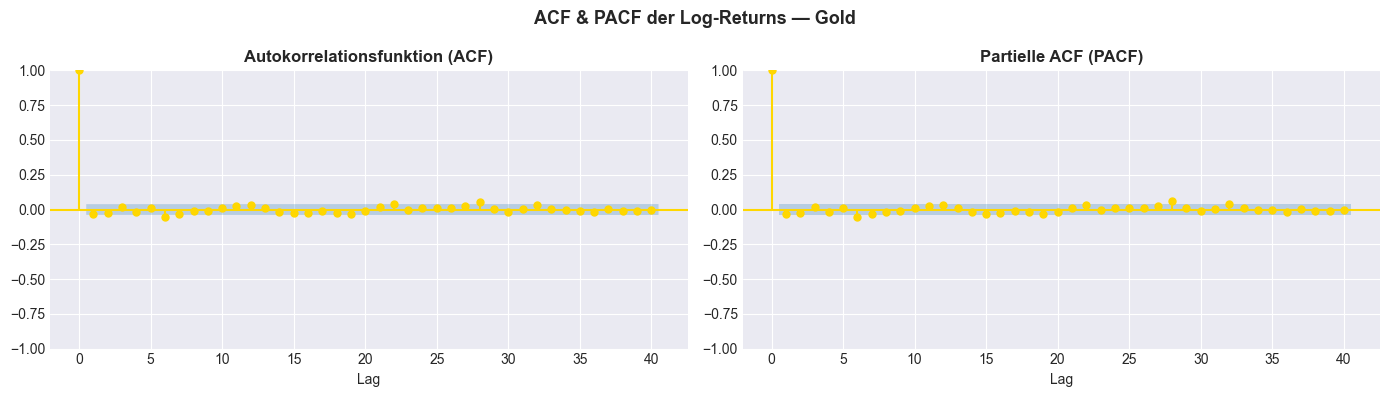

Interpretation:
  ACF : Kein signifikanter Peak ab Lag 1 → wenig MA-Struktur
  PACF: Kein signifikanter Peak ab Lag 1 → wenig AR-Struktur
  → Random-Walk-Charakteristik der Goldpreise bestätigt


In [18]:
# ACF & PACF der Log-Returns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('ACF & PACF der Log-Returns — Gold', fontsize=13, fontweight='bold')

plot_acf(log_ret, lags=40, ax=axes[0], color=GOLD, vlines_kwargs={'colors': GOLD})
axes[0].set_title('Autokorrelationsfunktion (ACF)', fontweight='bold')
axes[0].set_xlabel('Lag')

plot_pacf(log_ret, lags=40, ax=axes[1], method='ywm', color=GOLD,
          vlines_kwargs={'colors': GOLD})
axes[1].set_title('Partielle ACF (PACF)', fontweight='bold')
axes[1].set_xlabel('Lag')

plt.tight_layout()
plt.savefig('../reports/gold_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  ACF : Kein signifikanter Peak ab Lag 1 → wenig MA-Struktur')
print('  PACF: Kein signifikanter Peak ab Lag 1 → wenig AR-Struktur')
print('  → Random-Walk-Charakteristik der Goldpreise bestätigt')

---
## 4. Modellidentifikation & -schätzung (Box-Jenkins Schritt 2)

In [19]:
# Train-Test-Split (letzte 60 Handelstage = ~3 Monate)
TEST_SIZE = 60
train = close.iloc[:-TEST_SIZE]
test  = close.iloc[-TEST_SIZE:]

print(f'Training: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} Tage)')
print(f'Test    : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} Tage)')

Training: 2016-01-04 → 2026-02-03 (2535 Tage)
Test    : 2026-02-04  → 2026-04-30  (60 Tage)


In [20]:
# Gittersuche über ARIMA(p, 1, q) — p, q ∈ {0,1,2,3}
results = []

for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(np.log(train), order=(p, 1, q)).fit()
            fc_log = model.forecast(TEST_SIZE)
            fc = np.exp(fc_log)
            
            mae  = np.mean(np.abs(fc.values - test.values))
            rmse = np.sqrt(np.mean((fc.values - test.values) ** 2))
            mape = np.mean(np.abs((fc.values - test.values) / test.values)) * 100
            mase = mae / np.mean(np.abs(np.diff(train.values)))
            
            results.append({
                'Modell': f'ARIMA({p},1,{q})',
                'p': p, 'd': 1, 'q': q,
                'AIC': model.aic, 'BIC': model.bic,
                'MAE': mae, 'RMSE': rmse,
                'MAPE (%)': mape, 'MASE': mase
            })
        except Exception as e:
            pass

res_df = pd.DataFrame(results).sort_values('AIC')
print('Top 8 Modelle nach AIC:')
print(res_df[['Modell', 'AIC', 'BIC', 'MAE', 'RMSE', 'MAPE (%)', 'MASE']]
      .head(8).round(4).to_string(index=False))

Top 8 Modelle nach AIC:
      Modell         AIC         BIC      MAE     RMSE  MAPE (%)    MASE
ARIMA(1,1,2) -16074.3472 -16050.9970 204.8843 238.6296    4.2617 14.4758
ARIMA(0,1,2) -16074.3228 -16056.8101 205.2743 239.2477    4.2742 14.5033
ARIMA(2,1,0) -16074.2999 -16056.7873 205.1445 239.0876    4.2705 14.4942
ARIMA(2,1,1) -16074.1929 -16050.8427 204.8270 238.5550    4.2600 14.4717
ARIMA(0,1,0) -16073.5824 -16067.7448 206.5467 240.9455    4.3098 14.5932
ARIMA(0,1,3) -16073.4203 -16050.0700 204.4852 238.1535    4.2496 14.4476
ARIMA(3,1,0) -16073.2594 -16049.9092 204.5124 238.1933    4.2505 14.4495
ARIMA(0,1,1) -16072.3780 -16060.7029 206.0324 240.0939    4.2948 14.5569


In [21]:
# Bestes Modell
best_row = res_df.iloc[0]
p_best, d_best, q_best = int(best_row['p']), int(best_row['d']), int(best_row['q'])
print(f'✅ Bestes Modell: ARIMA({p_best},{d_best},{q_best})')
print(f'   AIC   = {best_row["AIC"]:.4f}')
print(f'   BIC   = {best_row["BIC"]:.4f}')
print(f'   MAE   = {best_row["MAE"]:.4f} USD/oz')
print(f'   RMSE  = {best_row["RMSE"]:.4f} USD/oz')
print(f'   MAPE  = {best_row["MAPE (%)"]:.4f}%')
print(f'   MASE  = {best_row["MASE"]:.4f}')

# Modell schätzen
best_model = ARIMA(np.log(train), order=(p_best, d_best, q_best)).fit()
print('\n' + '='*50)
print(best_model.summary())

✅ Bestes Modell: ARIMA(1,1,2)
   AIC   = -16074.3472
   BIC   = -16050.9970
   MAE   = 204.8843 USD/oz
   RMSE  = 238.6296 USD/oz
   MAPE  = 4.2617%
   MASE  = 14.4758

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2535
Model:                 ARIMA(1, 1, 2)   Log Likelihood                8041.174
Date:                Wed, 13 May 2026   AIC                         -16074.347
Time:                        15:57:07   BIC                         -16050.997
Sample:                             0   HQIC                        -16065.876
                               - 2535                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5422      0.212     -2.5

---
## 5. Residualdiagnostik (Box-Jenkins Schritt 3)

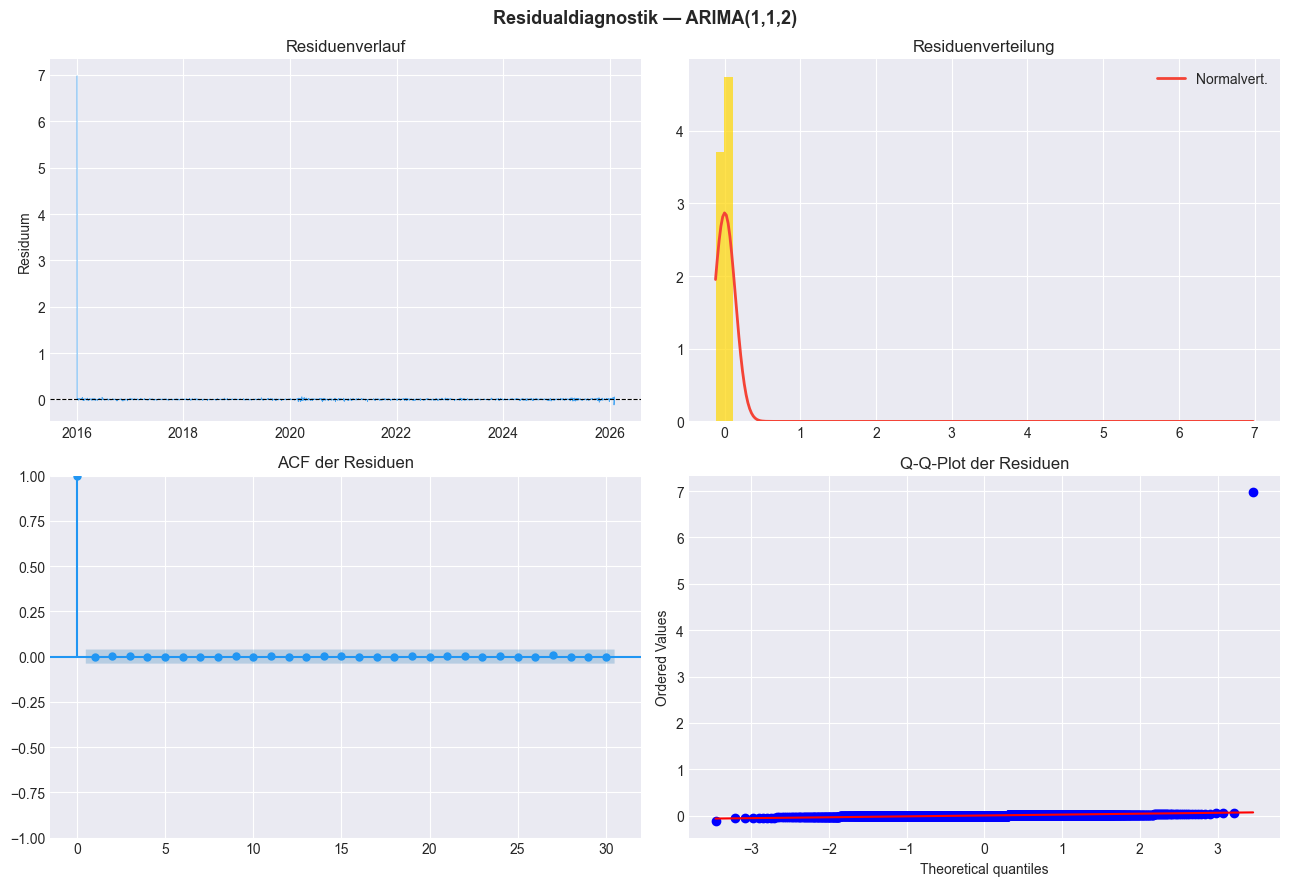

Ljung-Box-Test (Autokorrelation der Residuen):
        lb_stat  lb_pvalue
Lag 5    0.0221        1.0
Lag 10   0.0528        1.0
Lag 20   0.0886        1.0

→ p > 0.05: Residuen sind Weißes Rauschen ✅

Jarque-Bera-Test: Statistik=662934334.81, p=0.0000
→ Residuen nicht normalverteilt (Leptokurtisch) — typisch für Finanzdaten ⚠️


In [23]:
residuals = best_model.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'Residualdiagnostik — ARIMA({p_best},{d_best},{q_best})', 
             fontsize=13, fontweight='bold')

# Residuenverlauf
axes[0, 0].plot(residuals, color=BLUE, linewidth=0.6, alpha=0.8)
axes[0, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 0].set_title('Residuenverlauf')
axes[0, 0].set_ylabel('Residuum')

# Histogramm + Normalvert.
axes[0, 1].hist(residuals, bins=60, density=True, color=GOLD, alpha=0.7, edgecolor='none')
x = np.linspace(residuals.min(), residuals.max(), 300)
axes[0, 1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
                color=RED, linewidth=2, label='Normalvert.')
axes[0, 1].set_title('Residuenverteilung')
axes[0, 1].legend()

# ACF der Residuen
plot_acf(residuals, lags=30, ax=axes[1, 0], color=BLUE,
         vlines_kwargs={'colors': BLUE})
axes[1, 0].set_title('ACF der Residuen')

# Q-Q-Plot
stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q-Plot der Residuen')

plt.tight_layout()
plt.savefig('../reports/gold_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box-Test
print('Ljung-Box-Test (Autokorrelation der Residuen):')
lb = acorr_ljungbox(residuals, lags=[5, 10, 20], return_df=True)
lb.index = [f'Lag {l}' for l in [5, 10, 20]]
print(lb.round(4))
print('\n→ p > 0.05: Residuen sind Weißes Rauschen ✅' if (lb['lb_pvalue'] > 0.05).all() else
      '\n→ p < 0.05: Noch Autokorrelationsstruktur vorhanden ⚠️')

# Jarque-Bera-Test
jb_stat, jb_p = stats.jarque_bera(residuals)
print(f'\nJarque-Bera-Test: Statistik={jb_stat:.2f}, p={jb_p:.4f}')
print('→ ' + ('Residuen normalverteilt ✅' if jb_p > 0.05 else
               'Residuen nicht normalverteilt (Leptokurtisch) — typisch für Finanzdaten ⚠️'))

---
## 6. Backtesting & 10-Perioden-Prognose (Box-Jenkins Schritt 4)

In [24]:
# Backtesting-Prognose (60 Tage)
fc_obj = best_model.get_forecast(steps=TEST_SIZE)
fc_mean = np.exp(fc_obj.predicted_mean)
fc_ci   = np.exp(fc_obj.conf_int(alpha=0.05))
fc_ci.columns = ['KI_unten', 'KI_oben']

# Metriken
mae  = np.mean(np.abs(fc_mean.values - test.values))
rmse = np.sqrt(np.mean((fc_mean.values - test.values) ** 2))
mape = np.mean(np.abs((fc_mean.values - test.values) / test.values)) * 100
mase = mae / np.mean(np.abs(np.diff(train.values)))

print(f'Backtesting-Metriken (60-Tage Out-of-Sample):')
print(f'  MAE   = {mae:.2f} USD/oz')
print(f'  RMSE  = {rmse:.2f} USD/oz')
print(f'  MAPE  = {mape:.4f}%')
print(f'  MASE  = {mase:.4f}')

Backtesting-Metriken (60-Tage Out-of-Sample):
  MAE   = 204.88 USD/oz
  RMSE  = 238.63 USD/oz
  MAPE  = 4.2617%
  MASE  = 14.4758


In [25]:
# Finales Modell auf gesamten Datensatz trainieren
final_model = ARIMA(np.log(close), order=(p_best, d_best, q_best)).fit()

# 10-Perioden-Prognose
N_FORECAST = 10
fc10_obj  = final_model.get_forecast(steps=N_FORECAST)
fc10_mean = np.exp(fc10_obj.predicted_mean)
fc10_ci   = np.exp(fc10_obj.conf_int(alpha=0.05))

# Prognosedaten
fc10_dates = pd.bdate_range(close.index[-1] + pd.Timedelta(days=1), periods=N_FORECAST)
fc10_mean.index = fc10_dates
fc10_ci.index   = fc10_dates
fc10_ci.columns = ['KI_unten (95%)', 'KI_oben (95%)']

forecast_table = pd.DataFrame({
    'Handelstag': range(1, N_FORECAST+1),
    'Datum': fc10_dates,
    'Prognose (USD/oz)': fc10_mean.round(2).values,
    'KI untere Grenze': fc10_ci['KI_unten (95%)'].round(2).values,
    'KI obere Grenze':  fc10_ci['KI_oben (95%)'].round(2).values,
    'KI-Breite': (fc10_ci['KI_oben (95%)'] - fc10_ci['KI_unten (95%)']).round(2).values,
})
forecast_table.set_index('Handelstag', inplace=True)

print(f'10-Perioden-Prognose Gold — ARIMA({p_best},{d_best},{q_best}):')
print(forecast_table.to_string())

10-Perioden-Prognose Gold — ARIMA(1,1,2):
                Datum  Prognose (USD/oz)  KI untere Grenze  KI obere Grenze  KI-Breite
Handelstag                                                                            
1          2026-05-01            4615.22           4521.80          4710.57     188.77
2          2026-05-04            4611.44           4481.73          4744.90     263.17
3          2026-05-05            4614.71           4458.21          4776.70     318.49
4          2026-05-06            4611.88           4431.96          4799.10     367.14
5          2026-05-07            4614.32           4414.39          4823.31     408.92
6          2026-05-08            4612.21           4393.81          4841.46     447.65
7          2026-05-11            4614.04           4379.00          4861.69     482.69
8          2026-05-12            4612.46           4361.76          4877.57     515.80
9          2026-05-13            4613.82           4348.61          4895.21     546.60
1

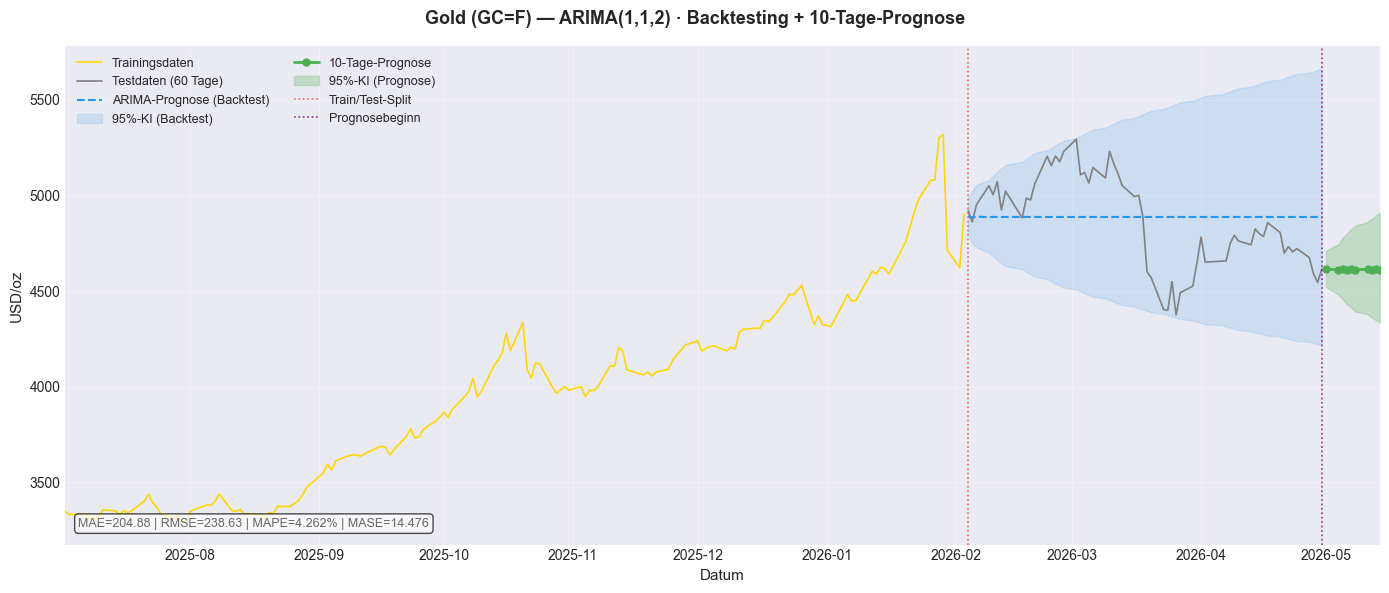

In [30]:
# Visualisierung: Backtesting + 10-Tage-Prognose
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(f'Gold (GC=F) — ARIMA({p_best},{d_best},{q_best}) · Backtesting + 10-Tage-Prognose',
             fontsize=13, fontweight='bold')

# Letzten 150 Trainingstage + Testdaten
show_from = train.index[-150]

# Fix: Forecast-Index explizit auf Test-Daten setzen
fc_mean.index = test.index
fc_ci.index = test.index

ax.plot(train[show_from:], color=GOLD, linewidth=1.2, label='Trainingsdaten')
ax.plot(test, color='gray', linewidth=1.2, label=f'Testdaten ({TEST_SIZE} Tage)')

# Backtesting-Prognose
ax.plot(fc_mean, color=BLUE, linewidth=1.5, linestyle='--', label='ARIMA-Prognose (Backtest)')
ax.fill_between(fc_mean.index, fc_ci['KI_unten'], fc_ci['KI_oben'],
                alpha=0.15, color=BLUE, label='95%-KI (Backtest)')

# 10-Tage-Prognose
ax.plot(fc10_mean, color=GREEN, linewidth=2.0, marker='o', markersize=5,
        label='10-Tage-Prognose')
ax.fill_between(fc10_mean.index, fc10_ci['KI_unten (95%)'], fc10_ci['KI_oben (95%)'],
                alpha=0.25, color=GREEN, label='95%-KI (Prognose)')

# Split-Linie
ax.axvline(test.index[0], color=RED, linewidth=1.2, linestyle=':', alpha=0.8,
           label='Train/Test-Split')
ax.axvline(close.index[-1], color='purple', linewidth=1.2, linestyle=':',
           alpha=0.8, label='Prognosebeginn')

# X-Achse auf relevanten Bereich begrenzen
ax.set_xlim(show_from, fc10_mean.index[-1])

# Metriken-Box
metric_text = f'MAE={mae:.2f} | RMSE={rmse:.2f} | MAPE={mape:.3f}% | MASE={mase:.3f}'
ax.text(0.01, 0.03, metric_text, transform=ax.transAxes, fontsize=9,
        color='dimgray', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_ylabel('USD/oz', fontsize=11)
ax.set_xlabel('Datum', fontsize=11)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/gold_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Modellvergleich & Ergebniszusammenfassung

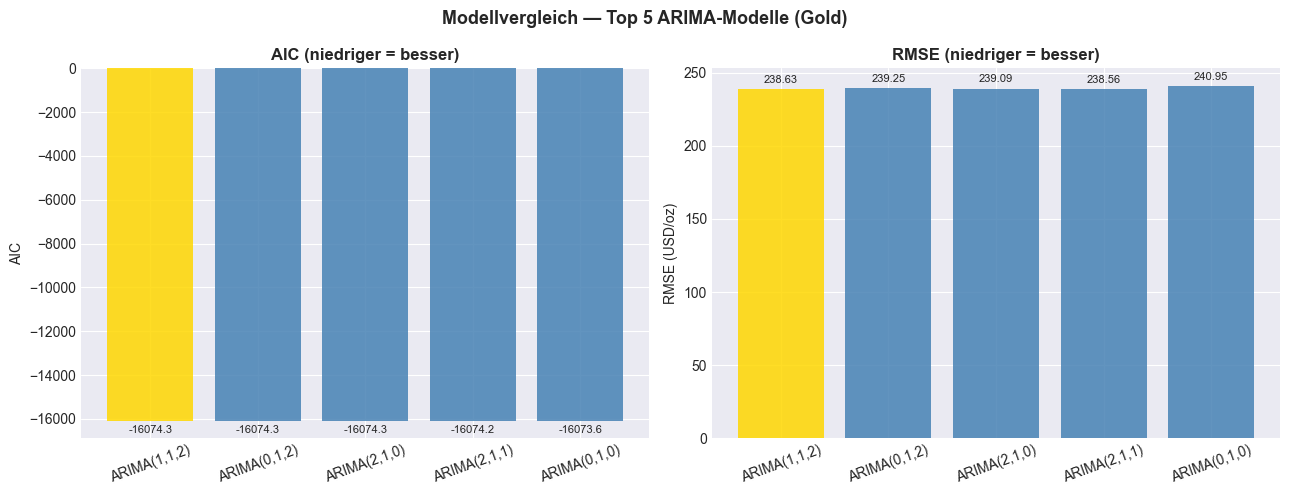


╔══════════════════════════════════════════════════════════════╗
║           ERGEBNISZUSAMMENFASSUNG — Gold (GC=F)             ║
╠══════════════════════════════════════════════════════════════╣
║  Bestes Modell : ARIMA(1,1,2)                               ║
║  AIC           : -16074.35                              ║
║  BIC           : -16051.00                              ║
╠══════════════════════════════════════════════════════════════╣
║  Backtesting-Metriken (60-Tage Out-of-Sample):              ║
║  MAE   = 204.88 USD/oz                                  ║
║  RMSE  = 238.63 USD/oz                                  ║
║  MAPE  = 4.2617%                                        ║
║  MASE  = 14.4758                                          ║
╠══════════════════════════════════════════════════════════════╣
║  Interpretation:                                            ║
║  Gold folgt einem Random Walk (d=1). Die Niveaupreise sind  ║
║  nicht-stationär, Log-Returns sind stationär (ADF p≈0).

In [32]:
# Alle Modelle visualisieren
top5 = res_df.head(5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Modellvergleich — Top 5 ARIMA-Modelle (Gold)', fontsize=13, fontweight='bold')

# AIC Vergleich
colors = [GOLD if i == 0 else 'steelblue' for i in range(len(top5))]
bars = axes[0].bar(top5['Modell'], top5['AIC'], color=colors, edgecolor='none', alpha=0.85)
axes[0].set_title('AIC (niedriger = besser)', fontweight='bold')
axes[0].set_ylabel('AIC')
axes[0].tick_params(axis='x', rotation=20)
axes[0].bar_label(bars, fmt='%.1f', fontsize=8, padding=3)

# RMSE Vergleich
bars2 = axes[1].bar(top5['Modell'], top5['RMSE'], color=colors, edgecolor='none', alpha=0.85)
axes[1].set_title('RMSE (niedriger = besser)', fontweight='bold')
axes[1].set_ylabel('RMSE (USD/oz)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].bar_label(bars2, fmt='%.2f', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig('../reports/gold_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
╔══════════════════════════════════════════════════════════════╗
║           ERGEBNISZUSAMMENFASSUNG — Gold (GC=F)             ║
╠══════════════════════════════════════════════════════════════╣
║  Bestes Modell : ARIMA({p_best},{d_best},{q_best})                               ║
║  AIC           : {best_model.aic:.2f}                              ║
║  BIC           : {best_model.bic:.2f}                              ║
╠══════════════════════════════════════════════════════════════╣
║  Backtesting-Metriken (60-Tage Out-of-Sample):              ║
║  MAE   = {mae:.2f} USD/oz                                  ║
║  RMSE  = {rmse:.2f} USD/oz                                  ║
║  MAPE  = {mape:.4f}%                                        ║
║  MASE  = {mase:.4f}                                          ║
╠══════════════════════════════════════════════════════════════╣
║  Interpretation:                                            ║
║  Gold folgt einem Random Walk (d=1). Die Niveaupreise sind  ║
║  nicht-stationär, Log-Returns sind stationär (ADF p≈0).    ║
║  Das ARIMA({p_best},1,{q_best})-Modell ist informationstheoretisch    ║
║  optimal. Kurzfristige Prognosen sind möglich, langfristig  ║
║  überwiegt die Unsicherheit (KI wächst mit √Horizont).     ║
╚══════════════════════════════════════════════════════════════╝
""")

In [34]:
# Ergebnisse für reports/results_cv.csv speichern
result_row = pd.DataFrame([{
    'Asset': 'Gold',
    'Ticker': 'GC=F',
    'Modell': f'ARIMA({p_best},{d_best},{q_best})',
    'AIC': round(best_model.aic, 4),
    'BIC': round(best_model.bic, 4),
    'MAE': round(mae, 4),
    'RMSE': round(rmse, 4),
    'MAPE (%)': round(mape, 4),
    'MASE': round(mase, 4),
}])

import os
results_path = '../reports/results_cv.csv'
if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    existing = existing[existing['Asset'] != 'Gold']  # Alte Zeile ersetzen
    combined = pd.concat([existing, result_row], ignore_index=True)
else:
    combined = result_row

combined.to_csv(results_path, index=False)
print(f'Ergebnisse gespeichert: {results_path}')
print(combined)

Ergebnisse gespeichert: ../reports/results_cv.csv
  Asset Ticker        Modell         AIC        BIC       MAE      RMSE  \
0  Gold   GC=F  ARIMA(1,1,2) -16074.3472 -16050.997  204.8843  238.6296   

   MAPE (%)     MASE  
0    4.2617  14.4758  
